# Data Analyst Job Market Analysis

### Skills, Job Levels, Work Types & Geographic Trends

**Objective:**  
Analyze Data Analyst job postings to identify the most demanded skills,
job-level patterns, work arrangements, and geographic trends.

**Dataset:** Data Analyst Job Postings


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [3]:
df = pd.read_csv("../data/raw/postings.csv")

df.head()

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job level,job_type,job_summary,job_skills
0,"Data Analyst-SQL, Tableau",Zortech Solutions,"Mountain View, CA",https://www.linkedin.com/jobs/data-analyst-jobs,20-12-2023,Bloomington,United States,Associate,Onsite,NaN,NaN
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-research-insights-analyst-at-indiana-university-founda...,20-12-2023,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer who wants to contribute to a mission-driven and va...,"Data analysis, Market research, Survey development, Analytical methods, Quantitative initiatives..."
2,Business Systems Analyst `1,Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/business-systems-analyst-1-at-cook-medical-3774214533,20-12-2023,Bloomington,United States,Mid senior,Onsite,Overview\nThe Business Systems Analyst 1 performs analysis of system requirements in collaborati...,"Business Analysis, Technical Writing, Software Testing, Systems Development, Process Improvement..."
3,Senior VAT and Indirect Tax Analyst,Epic,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-vat-and-indirect-tax-analyst-at-epic-3681586974,20-12-2023,Bloomington,United States,Mid senior,Onsite,We're looking for an experienced tax professional to help our company continue its steady growth...,"Accounting, Finance, VAT/GST tax regimes, US and foreign tax laws, VAT and sales tax issues, Ind..."
4,Senior HRIS Analyst (Timekeeping and Payroll),Nordson Corporation,Greater Bloomington Area,https://www.linkedin.com/jobs/view/senior-hris-analyst-timekeeping-and-payroll-at-nordson-corpor...,20-12-2023,Bloomington,United States,Mid senior,Remote,Collaboration drives Nordson’s success as a market leader in Industrial Precision Solutions and ...,"Workday HCM, UKG Dimensions, Ceridian Dayforce, Reporting, Project management, Analytical skills..."


In [4]:
df.shape

(12894, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12894 entries, 0 to 12893
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_title       12894 non-null  object
 1   company         12894 non-null  object
 2   job_location    12894 non-null  object
 3   job_link        12894 non-null  object
 4   first_seen      12894 non-null  object
 5   search_city     12894 non-null  object
 6   search_country  12894 non-null  object
 7   job level       12894 non-null  object
 8   job_type        12894 non-null  object
 9   job_summary     12851 non-null  object
 10  job_skills      12705 non-null  object
dtypes: object(11)
memory usage: 1.1+ MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq
job_title,12894,6797,Business Analyst,438
company,12894,5283,ClearanceJobs,238
job_location,12894,2446,United States,247
job_link,12894,12894,https://www.linkedin.com/jobs/data-analyst-jobs,1
first_seen,12894,1,20-12-2023,12894
search_city,12894,834,Hollywood,150
search_country,12894,4,United States,10386
job level,12894,2,Mid senior,9691
job_type,12894,3,Onsite,6670
job_summary,12851,11163,We're looking for an experienced tax professional to help our company continue its steady growth...,97


In [7]:
missing_values = df.isnull().sum()

missing_values

job_title           0
company             0
job_location        0
job_link            0
first_seen          0
search_city         0
search_country      0
job level           0
job_type            0
job_summary        43
job_skills        189
dtype: int64

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

job_skills        1.465798
job_summary       0.333488
job_title         0.000000
job_location      0.000000
company           0.000000
job_link          0.000000
first_seen        0.000000
search_country    0.000000
search_city       0.000000
job_type          0.000000
job level         0.000000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
print("Job levels:")
print(df["job level"].value_counts())

print("\nJob types:")
print(df["job_type"].value_counts())

print("\nCountries:")
print(df["search_country"].value_counts().head(20))

Job levels:
job level
Mid senior    9691
Associate     3203
Name: count, dtype: int64

Job types:
job_type
Onsite    6670
Hybrid    4339
Remote    1885
Name: count, dtype: int64

Countries:
search_country
United States     10386
United Kingdom     1187
Canada              876
Australia           445
Name: count, dtype: int64


## 2. Data Cleaning

The raw dataset is preserved separately. A copy of the dataset is created
for cleaning and transformation so that the original data remains unchanged.

In [11]:
df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (12894, 11)


In [12]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_clean.columns

Index(['job_title', 'company', 'job_location', 'job_link', 'first_seen',
       'search_city', 'search_country', 'job_level', 'job_type', 'job_summary',
       'job_skills'],
      dtype='object')

In [13]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [14]:
df_clean["job_summary"] = df_clean["job_summary"].fillna("Not Available")

df_clean["job_skills"] = df_clean["job_skills"].fillna("Not Available")

In [15]:
df_clean.isnull().sum()

job_title         0
company           0
job_location      0
job_link          0
first_seen        0
search_city       0
search_country    0
job_level         0
job_type          0
job_summary       0
job_skills        0
dtype: int64

In [16]:
text_columns = [
    "job_title",
    "company",
    "job_location",
    "search_city",
    "search_country",
    "job_level",
    "job_type",
    "job_summary",
    "job_skills"
]

for column in text_columns:
    df_clean[column] = df_clean[column].astype(str).str.strip()

In [17]:
df_clean["first_seen"] = pd.to_datetime(
    df_clean["first_seen"],
    dayfirst=True,
    errors="coerce"
)

In [18]:
df_clean["first_seen"].dtype

dtype('<M8[ns]')

In [19]:
print("Invalid dates:", df_clean["first_seen"].isna().sum())

Invalid dates: 0


In [20]:
df_clean["year"] = df_clean["first_seen"].dt.year
df_clean["month"] = df_clean["first_seen"].dt.month
df_clean["month_name"] = df_clean["first_seen"].dt.month_name()

In [21]:
df_clean[["first_seen", "year", "month", "month_name"]].head()

,first_seen,year,month,month_name
0,2023-12-20,2023,12,December
1,2023-12-20,2023,12,December
2,2023-12-20,2023,12,December
3,2023-12-20,2023,12,December
4,2023-12-20,2023,12,December


In [22]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Rows: 12894
Columns: 14

Missing values:
job_title         0
company           0
job_location      0
job_link          0
first_seen        0
search_city       0
search_country    0
job_level         0
job_type          0
job_summary       0
job_skills        0
year              0
month             0
month_name        0
dtype: int64

Duplicate rows:
0


In [23]:
df_clean.to_csv(
    "../data/processed/cleaned_postings.csv",
    index=False
)

In [24]:
import os

print(os.path.exists("../data/processed/cleaned_postings.csv"))

True


## 3.1 Temporal Coverage of Job Postings

In [25]:
print("Earliest posting date:", df_clean["first_seen"].min())
print("Latest posting date:", df_clean["first_seen"].max())

print("\nPostings by year:")
print(df_clean["year"].value_counts().sort_index())

Earliest posting date: 2023-12-20 00:00:00
Latest posting date: 2023-12-20 00:00:00

Postings by year:
year
2023    12894
Name: count, dtype: int64


## 3.2 Job Level Distribution

In [26]:
job_level_counts = df_clean["job_level"].value_counts()

print(job_level_counts)

print("\nPercentage distribution:")
print((df_clean["job_level"].value_counts(normalize=True) * 100).round(2))

job_level
Mid senior    9691
Associate     3203
Name: count, dtype: int64

Percentage distribution:
job_level
Mid senior    75.16
Associate     24.84
Name: proportion, dtype: float64


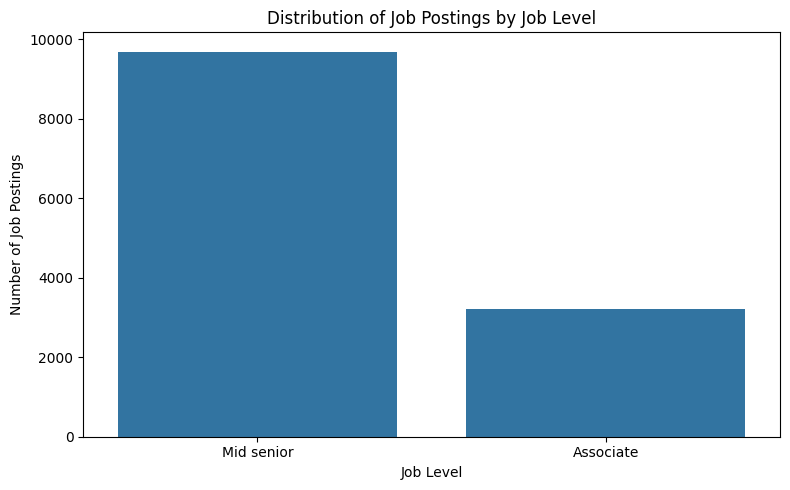

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="job_level",
    order=df_clean["job_level"].value_counts().index
)

plt.title("Distribution of Job Postings by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.3 Job Type / Work Type Distribution

In [28]:
job_type_counts = df_clean["job_type"].value_counts()

print(job_type_counts)

print("\nPercentage distribution:")
print(
    (df_clean["job_type"].value_counts(normalize=True) * 100)
    .round(2)
)

job_type
Onsite    6670
Hybrid    4339
Remote    1885
Name: count, dtype: int64

Percentage distribution:
job_type
Onsite    51.73
Hybrid    33.65
Remote    14.62
Name: proportion, dtype: float64


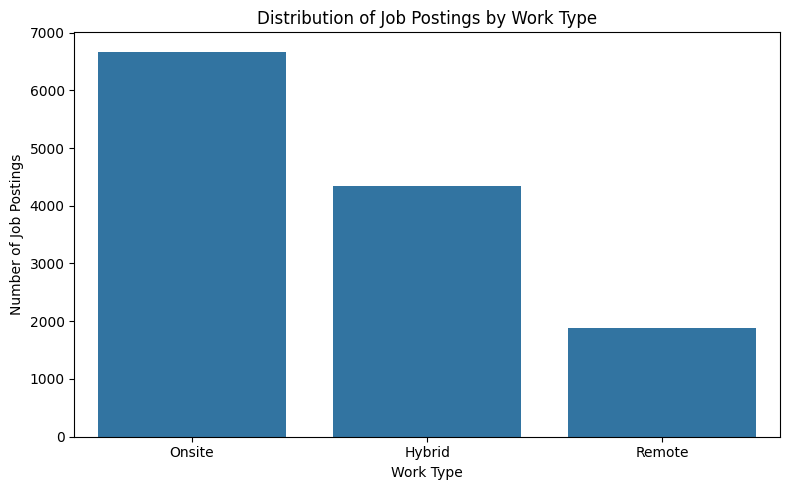

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="job_type",
    order=df_clean["job_type"].value_counts().index
)

plt.title("Distribution of Job Postings by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
plt.show()

## 3.4 Geographic Distribution of Job Postings

In [30]:
country_counts = df_clean["search_country"].value_counts()

print(country_counts)

search_country
United States     10386
United Kingdom     1187
Canada              876
Australia           445
Name: count, dtype: int64


In [31]:
top_countries = df_clean["search_country"].value_counts().head(10)

print(top_countries)

search_country
United States     10386
United Kingdom     1187
Canada              876
Australia           445
Name: count, dtype: int64


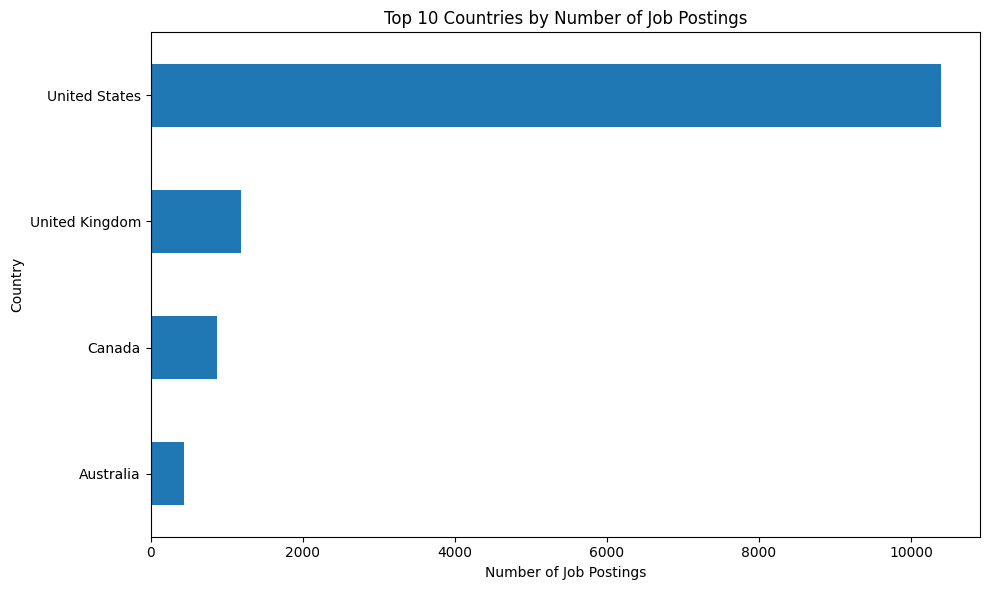

In [32]:
plt.figure(figsize=(10, 6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [33]:
city_counts = df_clean["search_city"].value_counts()

print(city_counts.head(10))

search_city
Hollywood          150
Beverly            115
Atlanta            114
Pasadena           112
Garland            105
Eastchester        104
Montpelier         103
New South Wales    101
Alexandria          99
Greater London      97
Name: count, dtype: int64


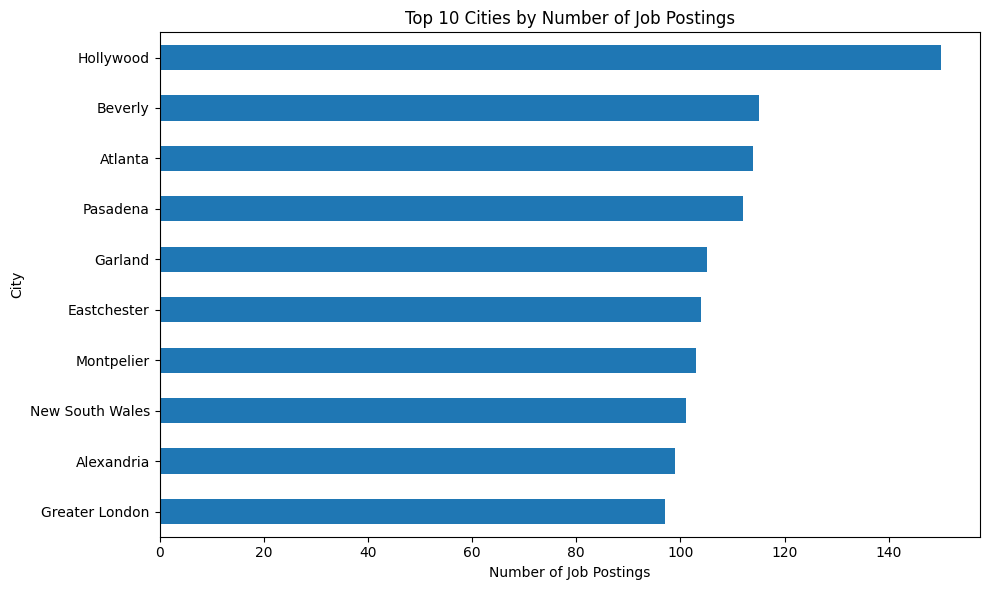

In [34]:
top_cities = df_clean["search_city"].value_counts().head(10)

plt.figure(figsize=(10, 6))

top_cities.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Number of Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## 3.5 Skill Demand Analysis

In [35]:
print(df_clean["job_skills"].head(10).to_string())

0                                                                                          Not Available
1    Data analysis, Market research, Survey development, Analytical methods, Quantitative initiatives...
2    Business Analysis, Technical Writing, Software Testing, Systems Development, Process Improvement...
3    Accounting, Finance, VAT/GST tax regimes, US and foreign tax laws, VAT and sales tax issues, Ind...
4    Workday HCM, UKG Dimensions, Ceridian Dayforce, Reporting, Project management, Analytical skills...
5    SAP Business Objects, SQL, Qlik, Data Modeling, Data Warehousing, Relational Databases, Data Vis...
6                                                                                          Not Available
7                                                                                          Not Available
8    Information technology, Microsoft Office, Data analysis, System design, Communication, Project m...
9    Business Analysis, Problem Solving, Root Cause Ana

In [36]:
skills_series = (
    df_clean["job_skills"]
    .loc[df_clean["job_skills"] != "Not Available"]
    .str.split(",")
    .explode()
    .str.strip()
)

skills_series.head(20)

1               Data analysis
1             Market research
1          Survey development
1          Analytical methods
1    Quantitative initiatives
1     Qualitative initiatives
1          Business solutions
1          Project management
1        Communication skills
1            Customer service
1        Statistical analysis
1          Data visualization
1           Data storytelling
1      Stakeholder engagement
1                     Windows
1                       Excel
1                        Word
1                  PowerPoint
1    Market research software
1                   Marketing
Name: job_skills, dtype: object

In [37]:
skill_counts = skills_series.value_counts()

print(skill_counts.head(20))

job_skills
SQL                       4286
Data Analysis             2828
Communication             2466
Tableau                   2153
Excel                     2150
Python                    2132
Data analysis             1819
Power BI                  1741
Project Management        1588
Reporting                 1389
Data Visualization        1389
Business Analysis         1217
R                         1211
Problem Solving            981
Teamwork                   976
Agile                      944
Project management         930
Microsoft Excel            923
Data visualization         907
Microsoft Office Suite     884
Name: count, dtype: int64


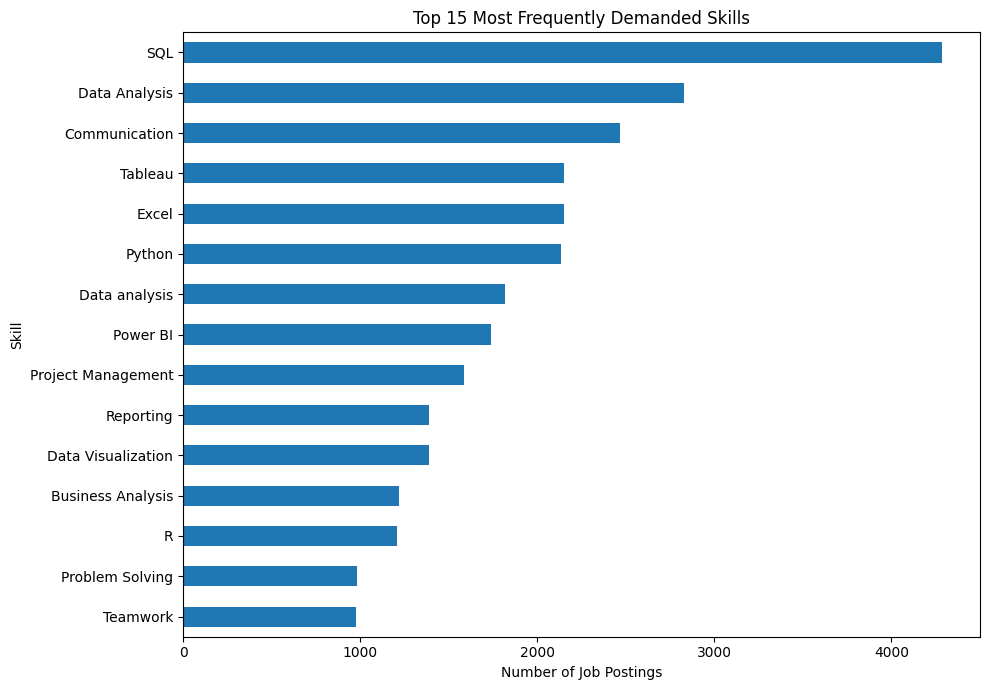

In [38]:
top_skills = skill_counts.head(15)

plt.figure(figsize=(10, 7))

top_skills.sort_values().plot(kind="barh")

plt.title("Top 15 Most Frequently Demanded Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [39]:
skills_clean = skills_series.str.lower().str.strip()

skills_clean.head(20)

1               data analysis
1             market research
1          survey development
1          analytical methods
1    quantitative initiatives
1     qualitative initiatives
1          business solutions
1          project management
1        communication skills
1            customer service
1        statistical analysis
1          data visualization
1           data storytelling
1      stakeholder engagement
1                     windows
1                       excel
1                        word
1                  powerpoint
1    market research software
1                   marketing
Name: job_skills, dtype: object

In [40]:
skill_counts_clean = skills_clean.value_counts()

print(skill_counts_clean.head(20))

job_skills
data analysis            4690
sql                      4289
project management       2531
communication            2475
data visualization       2327
tableau                  2168
excel                    2155
python                   2144
power bi                 1749
business analysis        1623
reporting                1394
problem solving          1362
business intelligence    1246
r                        1218
communication skills     1213
data analytics           1164
analytical skills        1153
data management          1011
teamwork                  982
data mining               952
Name: count, dtype: int64


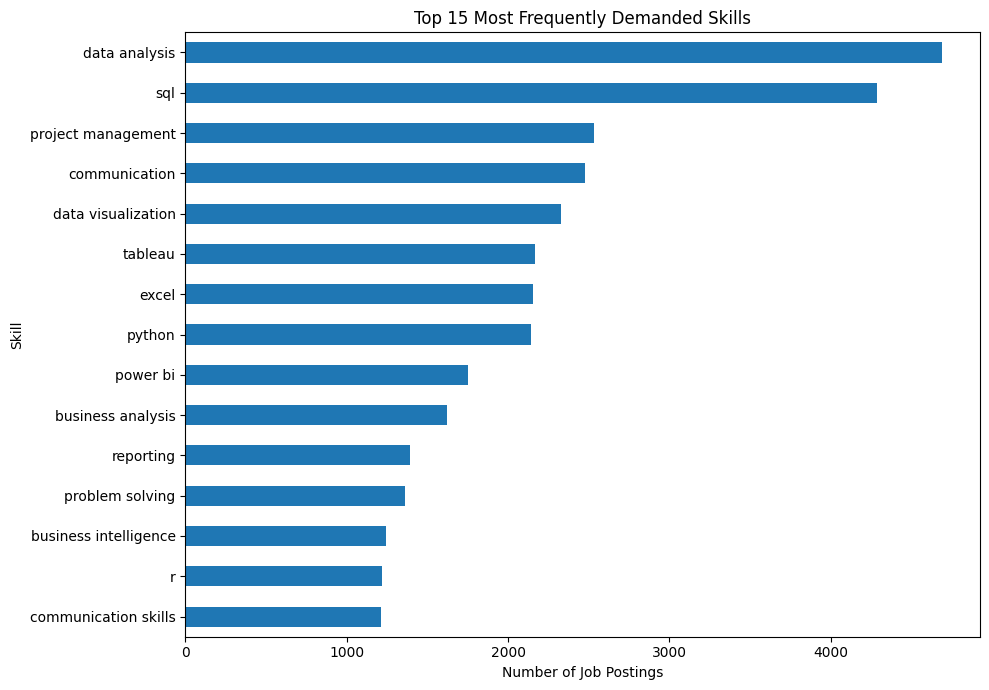

In [41]:
top_skills_clean = skill_counts_clean.head(15)

plt.figure(figsize=(10, 7))

top_skills_clean.sort_values().plot(kind="barh")

plt.title("Top 15 Most Frequently Demanded Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [42]:
core_skills = [
    "sql",
    "python",
    "excel",
    "power bi",
    "tableau"
]

core_skill_counts = skill_counts_clean[
    skill_counts_clean.index.isin(core_skills)
]

print(core_skill_counts)

job_skills
sql         4289
tableau     2168
excel       2155
python      2144
power bi    1749
Name: count, dtype: int64


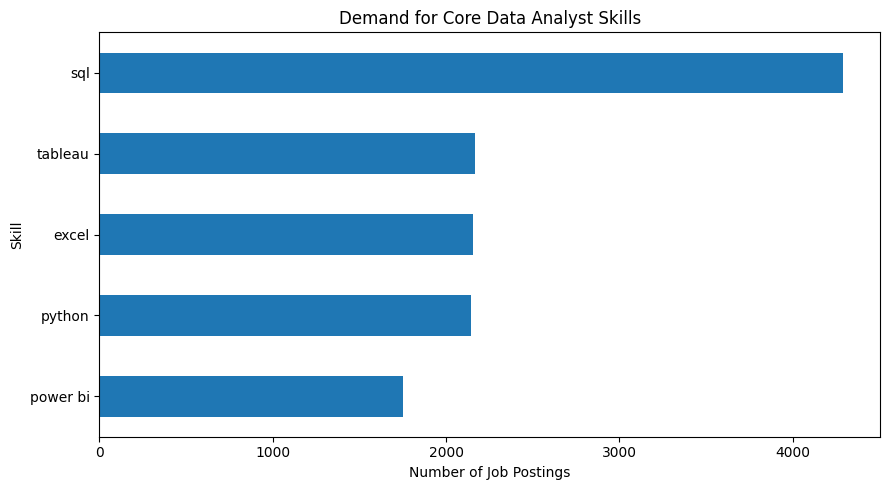

In [43]:
plt.figure(figsize=(9, 5))

core_skill_counts.sort_values().plot(kind="barh")

plt.title("Demand for Core Data Analyst Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [44]:
skills_by_level = df_clean[
    ["job_level", "job_skills"]
].copy()

skills_by_level = skills_by_level[
    skills_by_level["job_skills"] != "Not Available"
]

skills_by_level["job_skills"] = (
    skills_by_level["job_skills"]
    .str.split(",")
)

skills_by_level = skills_by_level.explode("job_skills")

skills_by_level["job_skills"] = (
    skills_by_level["job_skills"]
    .str.lower()
    .str.strip()
)

skills_by_level.head(20)

,job_level,job_skills
1,Mid senior,data analysis
1,Mid senior,market research
1,Mid senior,survey development
1,Mid senior,analytical methods
1,Mid senior,quantitative initiatives
1,Mid senior,qualitative initiatives
1,Mid senior,business solutions
1,Mid senior,project management
1,Mid senior,communication skills
1,Mid senior,customer service


In [45]:
top_skills_by_level = (
    skills_by_level
    .groupby("job_level")["job_skills"]
    .value_counts()
)

print(top_skills_by_level)

job_level   job_skills         
Associate   data analysis          1112
            sql                    1020
            project management      616
            excel                   608
            communication           596
                                   ... 
Mid senior  zoomtext                  1
            zscaler                   1
            zscaler zia and zpa       1
            zuora                     1
            zuora revenue             1
Name: count, Length: 53163, dtype: int64


In [46]:
for level in skills_by_level["job_level"].unique():
    print(f"\nTop 10 skills for {level}:")
    print(
        skills_by_level[
            skills_by_level["job_level"] == level
        ]["job_skills"]
        .value_counts()
        .head(10)
    )


Top 10 skills for Mid senior:
job_skills
data analysis         3578
sql                   3269
project management    1915
communication         1879
data visualization    1805
tableau               1671
python                1645
excel                 1547
power bi              1423
business analysis     1101
Name: count, dtype: int64

Top 10 skills for Associate:
job_skills
data analysis         1112
sql                   1020
project management     616
excel                  608
communication          596
business analysis      522
data visualization     522
python                 499
tableau                497
power bi               326
Name: count, dtype: int64


In [47]:
skill_level_counts = (
    skills_by_level
    .groupby(["job_level", "job_skills"])
    .size()
    .reset_index(name="skill_count")
)

level_totals = df_clean["job_level"].value_counts()

skill_level_counts["percentage"] = (
    skill_level_counts.apply(
        lambda row: (row["skill_count"] / level_totals[row["job_level"]]) * 100,
        axis=1
    )
)

skill_level_counts.head(20)

,job_level,job_skills,skill_count,percentage
0,Associate,* accountability,1,0.031221
1,Associate,* as 400,1,0.031221
2,Associate,* attention to detail,1,0.031221
3,Associate,* business process documentation,1,0.031221
4,Associate,* confluence,1,0.031221
5,Associate,* conversion rate optimization,1,0.031221
6,Associate,* curiosity,1,0.031221
7,Associate,* data analysis,2,0.062441
8,Associate,* data analytics,2,0.062441
9,Associate,* data consistency,1,0.031221


In [48]:
for level in ["Associate", "Mid senior"]:
    print(f"\nTop 10 skills for {level} by percentage:")
    
    result = (
        skill_level_counts[
            skill_level_counts["job_level"] == level
        ]
        .sort_values("percentage", ascending=False)
        .head(10)
    )
    
    print(
        result[
            ["job_skills", "skill_count", "percentage"]
        ].to_string(index=False)
    )


Top 10 skills for Associate by percentage:
        job_skills  skill_count  percentage
     data analysis         1112   34.717452
               sql         1020   31.845145
project management          616   19.231970
             excel          608   18.982204
     communication          596   18.607555
data visualization          522   16.297221
 business analysis          522   16.297221
            python          499   15.579145
           tableau          497   15.516703
          power bi          326   10.177958

Top 10 skills for Mid senior by percentage:
        job_skills  skill_count  percentage
     data analysis         3578   36.920854
               sql         3269   33.732329
project management         1915   19.760603
     communication         1879   19.389124
data visualization         1805   18.625529
           tableau         1671   17.242803
            python         1645   16.974512
             excel         1547   15.963265
          power bi         1423

In [49]:
core_level_data = skill_level_counts[
    skill_level_counts["job_skills"].isin(
        ["sql", "python", "excel", "power bi", "tableau"]
    )
]

core_level_pivot = core_level_data.pivot(
    index="job_skills",
    columns="job_level",
    values="percentage"
)

print(core_level_pivot)

job_level   Associate  Mid senior
job_skills                       
excel       18.982204   15.963265
power bi    10.177958   14.683727
python      15.579145   16.974512
sql         31.845145   33.732329
tableau     15.516703   17.242803


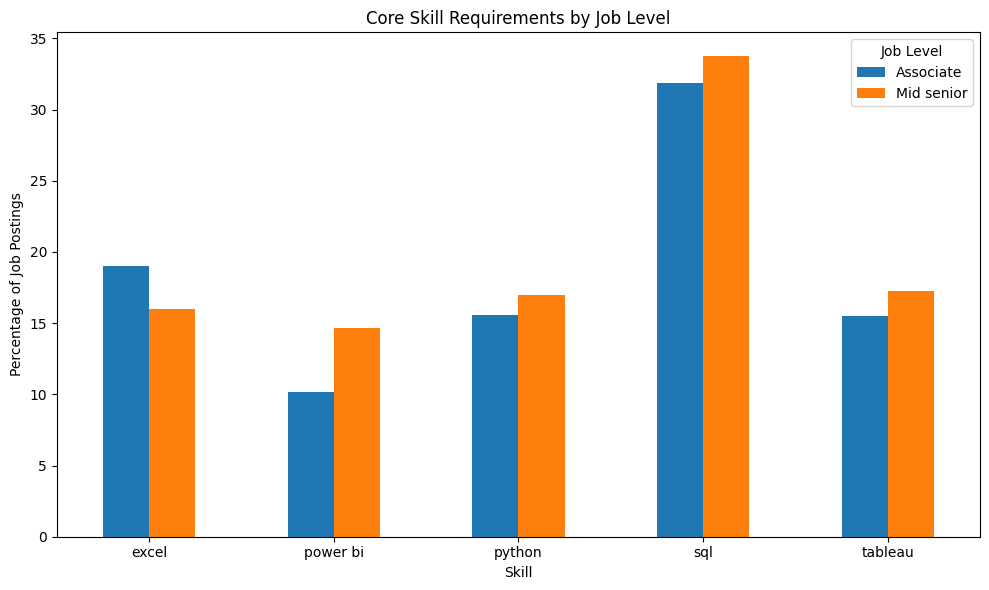

In [50]:
core_level_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Core Skill Requirements by Job Level")
plt.xlabel("Skill")
plt.ylabel("Percentage of Job Postings")
plt.xticks(rotation=0)
plt.legend(title="Job Level")
plt.tight_layout()
plt.show()

In [51]:
skills_by_work_type = df_clean[
    ["job_type", "job_skills"]
].copy()

skills_by_work_type = skills_by_work_type[
    skills_by_work_type["job_skills"] != "Not Available"
]

skills_by_work_type["job_skills"] = (
    skills_by_work_type["job_skills"]
    .str.split(",")
)

skills_by_work_type = skills_by_work_type.explode("job_skills")

skills_by_work_type["job_skills"] = (
    skills_by_work_type["job_skills"]
    .str.lower()
    .str.strip()
)

skills_by_work_type.head(20)

,job_type,job_skills
1,Onsite,data analysis
1,Onsite,market research
1,Onsite,survey development
1,Onsite,analytical methods
1,Onsite,quantitative initiatives
1,Onsite,qualitative initiatives
1,Onsite,business solutions
1,Onsite,project management
1,Onsite,communication skills
1,Onsite,customer service


In [52]:
core_work_data = skills_by_work_type[
    skills_by_work_type["job_skills"].isin(
        ["sql", "python", "excel", "power bi", "tableau"]
    )
]

core_work_counts = (
    core_work_data
    .groupby(["job_type", "job_skills"])
    .size()
    .reset_index(name="skill_count")
)

work_type_totals = df_clean["job_type"].value_counts()

core_work_counts["percentage"] = (
    core_work_counts.apply(
        lambda row: (
            row["skill_count"]
            / work_type_totals[row["job_type"]]
        ) * 100,
        axis=1
    )
)

print(core_work_counts.to_string(index=False))

job_type job_skills  skill_count  percentage
  Hybrid      excel          841   19.382346
  Hybrid   power bi          655   15.095644
  Hybrid     python          665   15.326112
  Hybrid        sql         1378   31.758470
  Hybrid    tableau          700   16.132749
  Onsite      excel         1050   15.742129
  Onsite   power bi          897   13.448276
  Onsite     python         1082   16.221889
  Onsite        sql         2187   32.788606
  Onsite    tableau         1169   17.526237
  Remote      excel          264   14.005305
  Remote   power bi          197   10.450928
  Remote     python          397   21.061008
  Remote        sql          724   38.408488
  Remote    tableau          299   15.862069


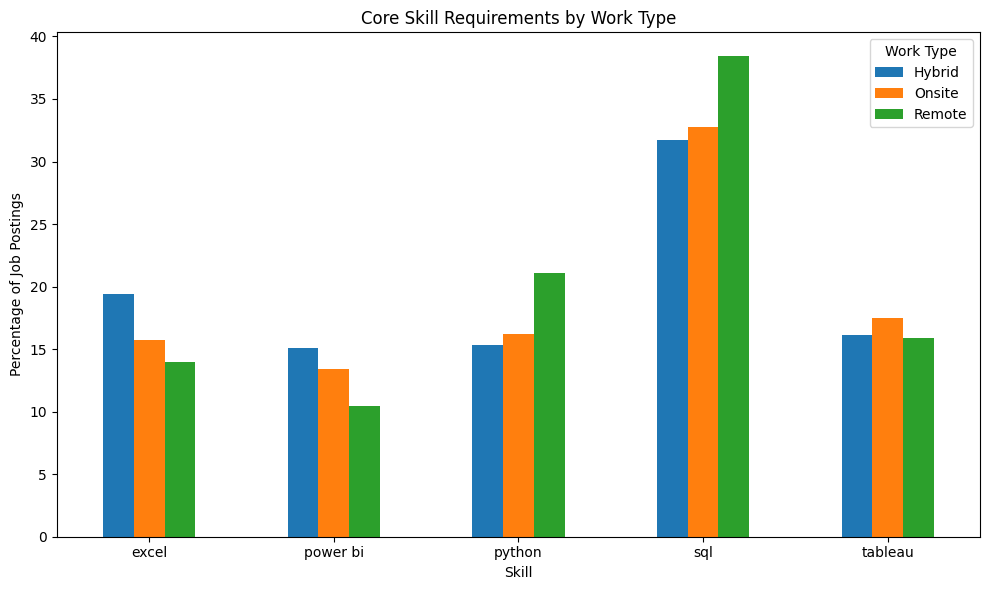

In [53]:
work_pivot = core_work_counts.pivot(
    index="job_skills",
    columns="job_type",
    values="percentage"
)

work_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Core Skill Requirements by Work Type")
plt.xlabel("Skill")
plt.ylabel("Percentage of Job Postings")
plt.xticks(rotation=0)
plt.legend(title="Work Type")
plt.tight_layout()
plt.show()

In [55]:
from itertools import combinations
from collections import Counter

skill_pairs = Counter()

for skills in df_clean["job_skills"]:
    if skills != "Not Available":
        skill_list = [
            skill.lower().strip()
            for skill in skills.split(",")
            if skill.strip()
        ]
        
        # Remove duplicate skills within the same job
        skill_list = sorted(set(skill_list))
        
        # Create all possible skill pairs
        for pair in combinations(skill_list, 2):
            skill_pairs[pair] += 1

skill_pair_counts = pd.DataFrame(
    skill_pairs.items(),
    columns=["skill_pair", "count"]
)

skill_pair_counts = skill_pair_counts.sort_values(
    "count",
    ascending=False
)

skill_pair_counts.head(15)

,skill_pair,count
2495,"(data analysis, sql)",2124
4851,"(python, sql)",1699
7396,"(sql, tableau)",1666
1378,"(data visualization, sql)",1560
102,"(data analysis, data visualization)",1542
1440,"(communication, data analysis)",1306
7302,"(data analysis, tableau)",1235
6930,"(data visualization, tableau)",1164
4849,"(python, r)",1095
7620,"(power bi, sql)",1090


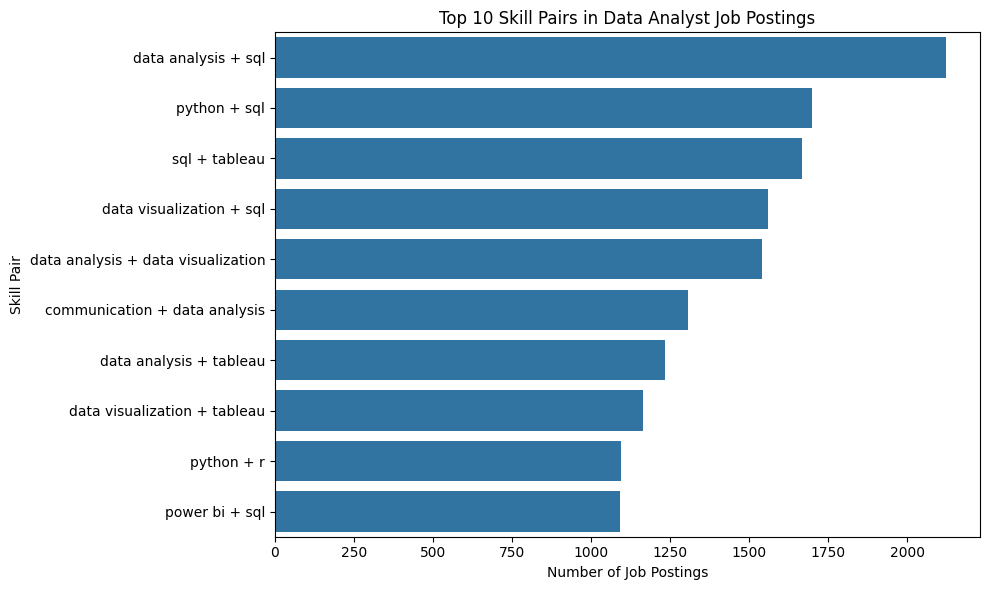

In [56]:
top_pairs = skill_pair_counts.head(10).copy()

top_pairs["skill_pair_label"] = top_pairs["skill_pair"].apply(
    lambda x: " + ".join(x)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_pairs,
    x="count",
    y="skill_pair_label"
)

plt.title("Top 10 Skill Pairs in Data Analyst Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill Pair")
plt.tight_layout()
plt.show()

In [57]:
from collections import Counter
import re

text = " ".join(
    df_clean["job_summary"]
    .loc[df_clean["job_summary"] != "Not Available"]
    .astype(str)
).lower()

words = re.findall(r"\b[a-zA-Z][a-zA-Z+#.-]*\b", text)

word_counts = Counter(words)

word_counts.most_common(30)

[('and', 444579),
 ('to', 234967),
 ('the', 203959),
 ('of', 167595),
 ('in', 118759),
 ('a', 116863),
 ('with', 101549),
 ('for', 87136),
 ('data', 75303),
 ('or', 70836),
 ('business', 60555),
 ('experience', 58405),
 ('is', 52731),
 ('our', 48079),
 ('as', 47827),
 ('we', 43599),
 ('you', 41766),
 ('work', 39234),
 ('on', 39064),
 ('be', 37245),
 ('will', 35557),
 ('are', 34662),
 ('s', 32177),
 ('an', 30987),
 ('skills', 30384),
 ('that', 29759),
 ('this', 28300),
 ('team', 27620),
 ('show', 25998),
 ('management', 25657)]

In [58]:
import re
from collections import Counter

stopwords = {
    "and", "to", "the", "of", "in", "a", "with", "for", "or",
    "is", "our", "as", "we", "you", "work", "on", "be", "will",
    "are", "an", "that", "this", "s", "show", "from", "by",
    "at", "their", "they", "your", "has", "have", "it", "who",
    "which", "can", "about", "more", "than", "into", "their",
    "job", "role", "team", "skills"
}

filtered_words = [
    word for word in words
    if word not in stopwords and len(word) > 2
]

keyword_counts = Counter(filtered_words)

keyword_counts.most_common(30)

[('data', 75303),
 ('business', 60555),
 ('experience', 58405),
 ('management', 25657),
 ('support', 25266),
 ('analysis', 24538),
 ('analyst', 23943),
 ('requirements', 23879),
 ('ability', 22436),
 ('information', 21934),
 ('all', 21606),
 ('other', 21000),
 ('systems', 18804),
 ('including', 18195),
 ('required', 18001),
 ('years', 17757),
 ('knowledge', 17012),
 ('working', 16636),
 ('development', 15864),
 ('position', 15022),
 ('process', 14531),
 ('solutions', 14364),
 ('strong', 14339),
 ('technical', 13945),
 ('project', 13936),
 ('financial', 13869),
 ('provide', 13738),
 ('less', 13616),
 ('reporting', 13298),
 ('company', 13162)]

In [59]:
additional_stopwords = {
    "all", "other", "including", "required", "years",
    "working", "position", "provide", "strong", "company",
    "ability", "requirements", "experience", "skills"
}

final_keywords = [
    word for word in filtered_words
    if word not in additional_stopwords
]

final_keyword_counts = Counter(final_keywords)

top_keywords = pd.DataFrame(
    final_keyword_counts.most_common(15),
    columns=["keyword", "count"]
)

top_keywords


,keyword,count
0,data,75303
1,business,60555
2,management,25657
3,support,25266
4,analysis,24538
5,analyst,23943
6,information,21934
7,systems,18804
8,knowledge,17012
9,development,15864


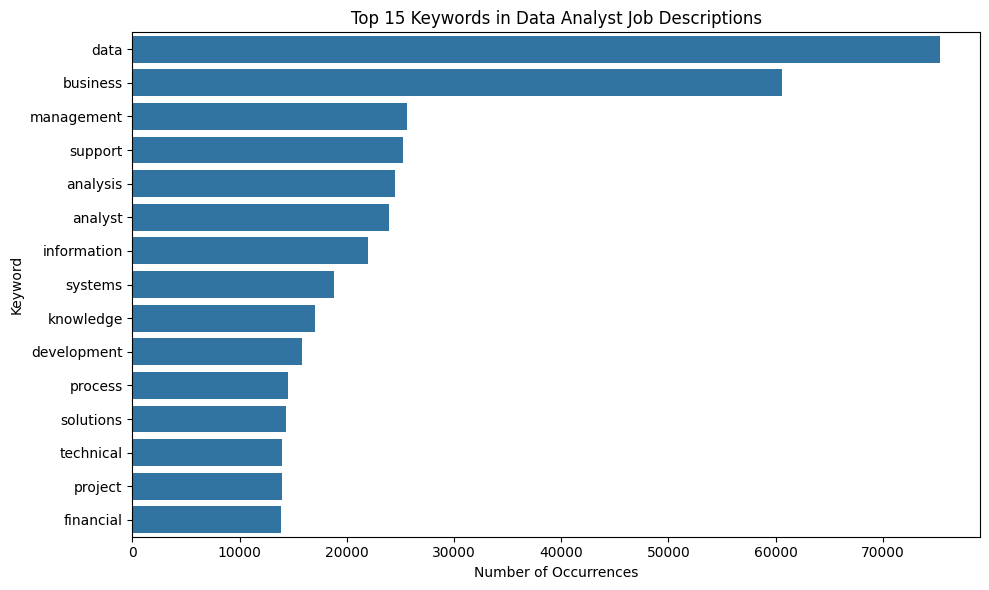

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_keywords,
    x="count",
    y="keyword"
)

plt.title("Top 15 Keywords in Data Analyst Job Descriptions")
plt.xlabel("Number of Occurrences")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()


In [61]:
# Find the top 10 search locations by number of job postings
top_locations = (
    df_clean["search_city"]
    .value_counts()
    .head(10)
    .index
)

location_work_type = df_clean[
    df_clean["search_city"].isin(top_locations)
]

# Calculate percentage distribution of work types within each location
location_work_pivot = pd.crosstab(
    location_work_type["search_city"],
    location_work_type["job_type"],
    normalize="index"
) * 100

location_work_pivot

job_type,Hybrid,Onsite,Remote
search_city,,,
Alexandria,40.404040,39.393939,20.202020
Atlanta,43.859649,39.473684,16.666667
Beverly,47.826087,28.695652,23.478261
Eastchester,35.576923,41.346154,23.076923
Garland,45.714286,41.904762,12.380952
Greater London,48.453608,41.237113,10.309278
Hollywood,22.000000,35.333333,42.666667
Montpelier,31.067961,57.281553,11.650485
New South Wales,43.564356,48.514851,7.920792


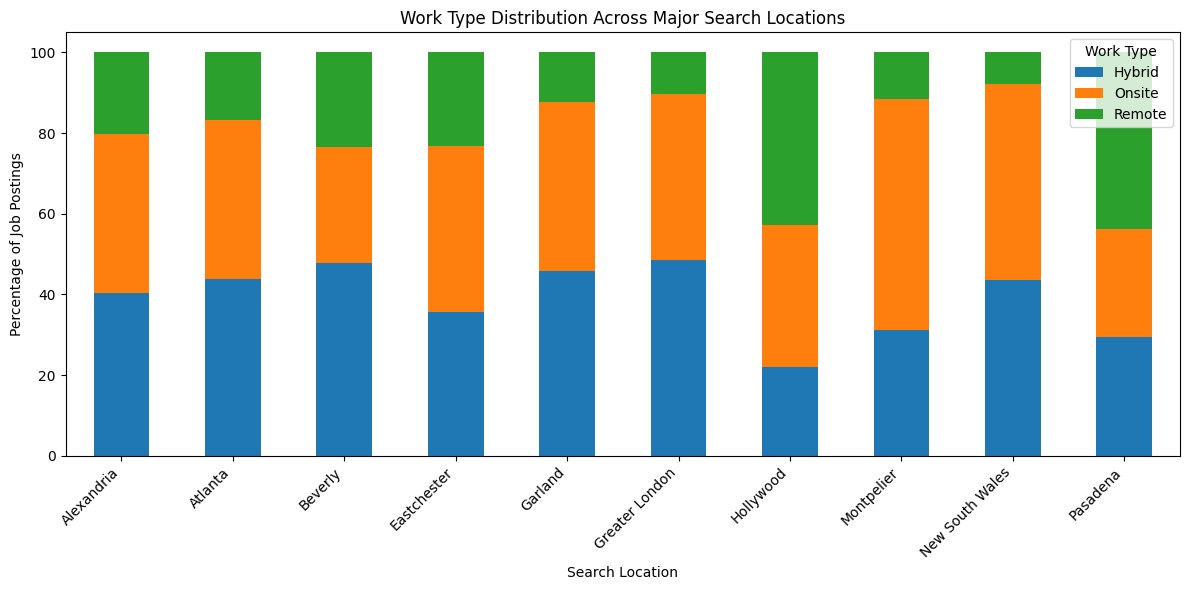

In [62]:
location_work_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Work Type Distribution Across Major Search Locations")
plt.xlabel("Search Location")
plt.ylabel("Percentage of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Work Type")
plt.tight_layout()
plt.show()

## EDA Summary

The exploratory data analysis provides several insights into the Data Analyst job market represented by this dataset.

- The dataset contains 12,894 Data Analyst job postings.
- The dataset represents a single-date snapshot from December 20, 2023, so it does not support time-trend analysis.
- Mid-senior positions account for the majority of postings, while Associate-level positions represent a smaller share.
- Onsite postings are the largest work-type category, followed by Hybrid and Remote postings.
- The United States contributes the largest number of postings among the four countries represented in the dataset.
- Data Analysis and SQL are among the most frequently mentioned skills.
- Among the selected core skills, SQL appears most frequently, followed by Tableau, Excel, Python, and Power BI.
- Skill co-occurrence analysis shows that Data Analysis + SQL is the most frequent skill combination, followed by Python + SQL and SQL + Tableau.
- Skill requirements vary across job levels and work types. For example, Python and SQL appear frequently across different work arrangements, while some visualization and spreadsheet skills show different distributions.
- Job-description keyword analysis highlights terms such as data, business, management, support, analysis, analyst, and information.
- Work-type distributions also vary across major search locations, showing differences in the proportions of onsite, hybrid, and remote postings.

### Dataset Limitation

The findings describe patterns within the available dataset and should not be interpreted as a complete representation of the global Data Analyst job market. The dataset contains postings from only four countries and represents a single-date snapshot.

In [63]:
import sqlite3

# Connect to SQLite database
conn = sqlite3.connect("../data/processed/job_market.db")

# Load cleaned DataFrame into SQLite
df_clean.to_sql(
    "job_postings",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite database created successfully.")

SQLite database created successfully.


In [64]:
query = """
SELECT COUNT(*) AS total_postings
FROM job_postings;
"""

sql_result = pd.read_sql_query(query, conn)

sql_result

,total_postings
0,12894


In [65]:
query = """
SELECT
    job_level,
    COUNT(*) AS total_postings,
    ROUND(
        COUNT(*) * 100.0 / (SELECT COUNT(*) FROM job_postings),
        2
    ) AS percentage
FROM job_postings
GROUP BY job_level
ORDER BY total_postings DESC;
"""

sql_level_result = pd.read_sql_query(query, conn)

sql_level_result

,job_level,total_postings,percentage
0,Mid senior,9691,75.16
1,Associate,3203,24.84


In [66]:
query = """
SELECT
    job_type,
    COUNT(*) AS total_postings,
    ROUND(
        COUNT(*) * 100.0 / (SELECT COUNT(*) FROM job_postings),
        2
    ) AS percentage
FROM job_postings
GROUP BY job_type
ORDER BY total_postings DESC;
"""

sql_work_result = pd.read_sql_query(query, conn)

sql_work_result

,job_type,total_postings,percentage
0,Onsite,6670,51.73
1,Hybrid,4339,33.65
2,Remote,1885,14.62


In [67]:
query = """
SELECT
    search_country,
    COUNT(*) AS total_postings,
    ROUND(
        COUNT(*) * 100.0 / (SELECT COUNT(*) FROM job_postings),
        2
    ) AS percentage
FROM job_postings
GROUP BY search_country
ORDER BY total_postings DESC;
"""

sql_country_result = pd.read_sql_query(query, conn)

sql_country_result

,search_country,total_postings,percentage
0,United States,10386,80.55
1,United Kingdom,1187,9.21
2,Canada,876,6.79
3,Australia,445,3.45


In [68]:
query = """
SELECT
    search_country,
    job_type,
    COUNT(*) AS total_postings,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (PARTITION BY search_country),
        2
    ) AS percentage
FROM job_postings
GROUP BY search_country, job_type
ORDER BY search_country, total_postings DESC;
"""

sql_country_work_result = pd.read_sql_query(query, conn)

sql_country_work_result

,search_country,job_type,total_postings,percentage
0,Australia,Onsite,229,51.46
1,Australia,Hybrid,173,38.88
2,Australia,Remote,43,9.66
3,Canada,Onsite,450,51.37
4,Canada,Hybrid,308,35.16
5,Canada,Remote,118,13.47
6,United Kingdom,Hybrid,568,47.85
7,United Kingdom,Onsite,517,43.56
8,United Kingdom,Remote,102,8.59
9,United States,Onsite,5474,52.71


In [69]:
query = """
SELECT
    search_city,
    COUNT(*) AS total_postings
FROM job_postings
GROUP BY search_city
ORDER BY total_postings DESC
LIMIT 10;
"""

sql_location_result = pd.read_sql_query(query, conn)

sql_location_result

,search_city,total_postings
0,Hollywood,150
1,Beverly,115
2,Atlanta,114
3,Pasadena,112
4,Garland,105
5,Eastchester,104
6,Montpelier,103
7,New South Wales,101
8,Alexandria,99
9,Greater London,97


In [70]:
query = """
SELECT
    job_level,
    job_type,
    COUNT(*) AS total_postings,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (PARTITION BY job_level),
        2
    ) AS percentage
FROM job_postings
GROUP BY job_level, job_type
ORDER BY job_level, total_postings DESC;
"""

sql_level_work_result = pd.read_sql_query(query, conn)

sql_level_work_result

,job_level,job_type,total_postings,percentage
0,Associate,Onsite,1518,47.39
1,Associate,Hybrid,1276,39.84
2,Associate,Remote,409,12.77
3,Mid senior,Onsite,5152,53.16
4,Mid senior,Hybrid,3063,31.61
5,Mid senior,Remote,1476,15.23


In [71]:
query = """
SELECT
    SUM(CASE WHEN LOWER(job_skills) LIKE '%sql%' THEN 1 ELSE 0 END) AS sql,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%python%' THEN 1 ELSE 0 END) AS python,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%excel%' THEN 1 ELSE 0 END) AS excel,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%power bi%' THEN 1 ELSE 0 END) AS power_bi,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%tableau%' THEN 1 ELSE 0 END) AS tableau
FROM job_postings;
"""

sql_core_skills_result = pd.read_sql_query(query, conn)

sql_core_skills_result

,sql,python,excel,power_bi,tableau
0,4844,2213,3800,1938,2194


In [72]:
query = """
SELECT
    job_level,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%sql%' THEN 1 ELSE 0 END) AS sql,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%python%' THEN 1 ELSE 0 END) AS python,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%excel%' THEN 1 ELSE 0 END) AS excel,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%power bi%' THEN 1 ELSE 0 END) AS power_bi,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%tableau%' THEN 1 ELSE 0 END) AS tableau
FROM job_postings
GROUP BY job_level
ORDER BY job_level;
"""

sql_skills_level_result = pd.read_sql_query(query, conn)

sql_skills_level_result

,job_level,sql,python,excel,power_bi,tableau
0,Associate,1140,519,1054,380,497
1,Mid senior,3704,1694,2746,1558,1697


In [73]:
query = """
SELECT
    job_type,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%sql%' THEN 1 ELSE 0 END) AS sql,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%python%' THEN 1 ELSE 0 END) AS python,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%excel%' THEN 1 ELSE 0 END) AS excel,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%power bi%' THEN 1 ELSE 0 END) AS power_bi,
    SUM(CASE WHEN LOWER(job_skills) LIKE '%tableau%' THEN 1 ELSE 0 END) AS tableau
FROM job_postings
GROUP BY job_type
ORDER BY job_type;
"""

sql_skills_work_result = pd.read_sql_query(query, conn)

sql_skills_work_result

,job_type,sql,python,excel,power_bi,tableau
0,Hybrid,1578,681,1492,713,704
1,Onsite,2460,1131,1844,1005,1178
2,Remote,806,401,464,220,312


## SQL Analysis Summary

SQL analysis was performed using a SQLite database created from the cleaned job-posting dataset.

The analysis examined job-level distribution, work-type distribution, country distribution, geographic locations, job-level and work-type combinations, and core skill mentions.

Key observations include:

- Mid-senior postings account for 75.16% of the dataset, while Associate postings account for 24.84%.
- Onsite postings represent 51.73% of all postings, followed by Hybrid at 33.65% and Remote at 14.62%.
- The United States represents 80.55% of the postings, followed by the United Kingdom, Canada, and Australia.
- Work-type distributions vary across countries. For example, Hybrid is the largest category in the United Kingdom, while Onsite is the largest category in Australia, Canada, and the United States.
- Onsite is the largest work-type category for both Associate and Mid-senior positions.
- SQL, Excel, Tableau, Python, and Power BI were examined using SQL-based text matching.
- Raw skill counts vary across job levels and work types partly because those groups contain different numbers of postings. Therefore, percentage-based comparisons from the exploratory analysis are more appropriate for comparing skill prevalence.

### SQL Methodological Note

Core skill counts obtained through SQL use text pattern matching with the `LIKE` operator. These counts may differ from the normalized skill counts obtained by splitting and exploding the `job_skills` field in Python. The Python-based normalized skill analysis is therefore used as the primary skill-frequency analysis.

# Key Findings

## Research Question 1: Which skills are most frequently demanded?

The most frequently mentioned skills in the dataset include Data Analysis, SQL, Project Management, Communication, Data Visualization, Tableau, Excel, and Python.

Data Analysis and SQL are among the most frequently occurring technical skills.

---

## Research Question 2: How frequently are core Data Analyst skills mentioned?

Among the selected core skills — SQL, Python, Excel, Power BI, and Tableau — SQL has the highest number of normalized skill mentions in the dataset.

The normalized skill counts are:

- SQL: 4,289
- Tableau: 2,168
- Excel: 2,155
- Python: 2,144
- Power BI: 1,749

These counts represent skill mentions after splitting and normalizing the job-skills field.

---

## Research Question 3: Which skills commonly occur together?

The most frequent skill combination is Data Analysis + SQL, appearing in 2,124 job postings.

Other frequently occurring combinations include:

- Python + SQL: 1,699
- SQL + Tableau: 1,666
- Data Visualization + SQL: 1,560
- Data Analysis + Data Visualization: 1,542

This shows that analytical, database, programming, and visualization skills frequently appear together in the dataset.

---

## Research Question 4: What is the distribution across job levels?

The dataset contains:

- Mid senior: 9,691 postings (75.16%)
- Associate: 3,203 postings (24.84%)

Therefore, the dataset contains a larger share of Mid senior postings.

---

## Research Question 5: How do skill requirements vary by job level?

Data Analysis and SQL are among the most frequently mentioned skills for both job levels.

The percentage-based analysis shows that some skills have different prevalence across levels. For example, Python, Tableau, Power BI, and Data Visualization have higher percentages among Mid senior postings, while Excel and Business Analysis have higher percentages among Associate postings.

---

## Research Question 6: What is the distribution of work types?

The dataset contains:

- Onsite: 6,670 postings (51.73%)
- Hybrid: 4,339 postings (33.65%)
- Remote: 1,885 postings (14.62%)

Onsite is the largest work-type category in the dataset.

---

## Research Question 7: Do skill requirements vary by work type?

Yes, the percentage-based analysis shows differences across work types.

SQL appears frequently across all three work types. Python has a higher percentage among Remote postings, while Excel and Power BI have their highest percentages among Hybrid postings in the analyzed dataset.

---

## Research Question 8: Which countries and search locations have the most postings?

The dataset contains postings from four countries:

- United States: 10,386 (80.55%)
- United Kingdom: 1,187 (9.21%)
- Canada: 876 (6.79%)
- Australia: 445 (3.45%)

The top search locations include Hollywood, Beverly, Atlanta, Pasadena, Garland, Eastchester, Montpelier, New South Wales, Alexandria, and Greater London.

The `search_city` field contains both cities and broader geographic areas, so these are referred to as search locations.

---

## Research Question 9: How does work type vary across major locations?

Work-type distributions differ across the major search locations.

For example:

- Hollywood has a relatively high Remote share.
- Pasadena also has a relatively high Remote share.
- Montpelier has the highest Onsite share among the listed top locations.
- Greater London has Hybrid as its largest work-type category.

These observations describe the dataset and should not be interpreted as general labor-market trends.

---

## Research Question 10: Which keywords are most frequent in job descriptions?

Frequently occurring job-description keywords include:

- Data
- Business
- Management
- Support
- Analysis
- Analyst
- Information
- Systems
- Knowledge
- Development
- Process
- Solutions
- Technical
- Project
- Financial

These keywords indicate that the job descriptions commonly combine data-analysis responsibilities with business, technical, process, project, and information-related activities.

---

## Overall Project Insight

The analysis shows that Data Analyst job postings in this dataset commonly combine analytical skills with SQL, visualization, programming, business, and reporting-related competencies. Skill requirements vary across job levels and work arrangements, while the geographic distribution is concentrated in a small number of countries.

Because the dataset represents a single-date snapshot and contains postings from only four countries, the findings describe patterns within this dataset rather than the entire global Data Analyst job market.

# Visual Insights

This section presents the key visualizations developed during the analysis to summarize important patterns in the Data Analyst job market dataset.

The visualizations cover:

1. Job Level Distribution
2. Work Type Distribution
3. Geographic Distribution
4. Top Skills
5. Core Skill Demand
6. Core Skills by Job Level
7. Core Skills by Work Type
8. Top Skill Co-occurrence
9. Job Description Keywords
10. Work Type Distribution Across Major Search Locations

# Conclusion

This project analyzed Data Analyst job postings to identify patterns in skill demand, job levels, work types, geographic distribution, skill combinations, and job-description keywords.

The analysis found that Data Analysis and SQL are among the most frequently mentioned skills, while SQL also commonly occurs alongside Python, Tableau, and data visualization skills. The dataset contains a larger proportion of Mid senior postings and Onsite work arrangements.

The analysis also shows that skill requirements differ across job levels and work types. Geographic analysis indicates that the postings are concentrated primarily in the United States, with smaller numbers from the United Kingdom, Canada, and Australia.

Overall, the project demonstrates how Python, Pandas, data visualization, text analysis, and SQL can be combined to analyze a real-world job-posting dataset and extract useful insights for understanding Data Analyst job requirements.


# Limitations

The following limitations should be considered when interpreting the results:

1. **Single-date snapshot:** All job postings in the dataset are from December 20, 2023. Therefore, the dataset does not support analysis of job-market trends over time.

2. **Geographic coverage:** The dataset contains postings from only four countries: the United States, United Kingdom, Canada, and Australia. Therefore, the findings should not be considered representative of the global Data Analyst job market.

3. **Dataset representation:** The dataset consists of collected job postings and may not represent every available Data Analyst position or every employer.

4. **Skill extraction:** Skills were analyzed from the available `job_skills` field. Different ways of writing similar skills may appear as separate terms.

5. **Keyword analysis:** Job-description keyword counts represent word occurrences, not the number of unique job postings containing each keyword.

6. **Text matching in SQL:** Some SQL skill queries use text pattern matching with the `LIKE` operator. As a result, SQL-based skill counts may differ from the normalized skill counts produced through Python-based skill extraction.

7. **Search location field:** The `search_city` column contains both cities and broader geographic areas. Therefore, it is treated as a search-location field rather than a strictly city-level field.

# Future Scope

The project can be extended in several ways:

1. **Time-series analysis:** A dataset containing job postings across multiple months or years could be used to analyze changes in skill demand and work arrangements over time.

2. **Salary analysis:** If salary information becomes available, salary ranges could be analyzed by skill, job level, location, and work type.

3. **Advanced NLP:** Natural Language Processing techniques could be applied to job descriptions to identify important topics, competencies, and emerging skills.

4. **Skill clustering:** Related skills could be grouped into categories such as programming, databases, visualization, business, and communication.

5. **Interactive dashboard:** The analysis could be converted into an interactive Power BI or Tableau dashboard for easier exploration.

6. **Broader geographic coverage:** Job postings from additional countries and regions could provide a more comprehensive view of the Data Analyst job market.

7. **Predictive analysis:** With a larger time-based dataset, machine learning techniques could be explored to study patterns in skill demand and job characteristics.